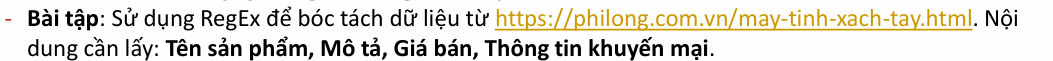

In [ ]:
import requests
import re
from bs4 import BeautifulSoup
import json

url = 'https://philong.com.vn/may-tinh-xach-tay.html'

r = requests.get(url)
r.status_code

In [ ]:
product_name = re.findall(r"data-name=\"([^\"]+\")", r.text)
product_name

In [ ]:
product_price = re.findall(r"data-price=\"([^\"]+)\"", r.text)
product_price = [int(i) for i in product_price]
product_price

In [ ]:
product_original_price = re.findall(r"class=\"p-unprice\">\s*([\d\.]+)", r.text) # maybe >=1 spaces 
product_original_price = [int(i.replace('.', '')) for i in product_original_price]
product_original_price

In [ ]:
summaries = re.findall(r'<div class="p-summary">(.*?)</div>', r.text, re.S) # *? = non-greedy -> stop at the first <div> encountered

clean_summaries = [
    re.sub(r"\s+", ' ', re.sub("</*\w+>",' ' ,i.strip())).strip()
    for i in summaries
]

clean_summaries

In [ ]:
data = []

for i, j, k, l in zip(product_name, product_price, product_original_price, clean_summaries):
    with open('chap1_regrex_data.json', 'a', encoding='utf-8') as f:
        data.append({
            'product_name': i,
            'product_price':j,
            'product_original_price':k,
            'description':l
        })

with open('chap2_regex_data.json', 'a', encoding='utf-8') as f:
    json.dump(data, f)

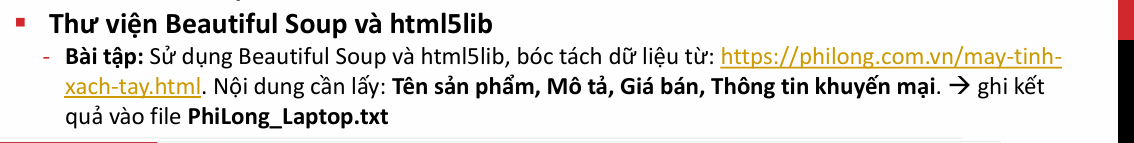

In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
url = 'https://philong.com.vn/may-tinh-xach-tay.html'

r = requests.get(url)
r.status_code

In [ ]:
soup = BeautifulSoup(r.text, 'html.parser')
soup

In [ ]:
cards = soup.find_all('div', class_='col-md-3 col-xl-2 col-sm-6 col-xs-6')

data = []

for card in cards:
    # find the tag first - find('a') then use get to get its attribute
    product_name = card.find('a').get('title')
    original_price = card.find('span', class_='p-unprice').text.strip()
    discount_price = card.find('span', class_='p-price').text.strip()
    summary= card.find('div', class_='p-summary').text.strip()
    data.append({
        'product_name':product_name,
        'original_price':original_price,
        'discount_price':discount_price,
        'summary':summary
    })

In [ ]:
import json

with open('chap2_bs4_data.json', 'a', encoding='utf-8') as f:
    json.dump(data, f)